# Lensless Fluorescent Microscopy

Using Neural Networks to eliminate noisy propogation in the Fraunhoffer Domain

In [24]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from scipy.fft import fft2, ifft2
import matplotlib.pyplot as plt

# ----------------------------
# PARAMETERS
# ----------------------------
wavelength = 520e-9
pixel_size = 6.5e-6
nx, ny = 32, 32
prop_distance = 0.01
mask_fraction = 0.5
n_train = 500
n_blobs = 5
batch_size = 4
n_epochs = 200

# ----------------------------
# RANDOM PHASE MASK
# ----------------------------
phase_mask = np.exp(1j * 2*np.pi*np.random.rand(nx, ny))

# ----------------------------
# FRESNEL PROPAGATION
# ----------------------------
def fresnel_propagate(Uin, z, wavelength, pixel_size):
    fx = np.fft.fftfreq(Uin.shape[0], pixel_size)
    fy = np.fft.fftfreq(Uin.shape[1], pixel_size)
    FX, FY = np.meshgrid(fx, fy)
    H = np.exp(-1j * np.pi * wavelength * z * (FX**2 + FY**2))
    Uout = ifft2(fft2(Uin) * H)
    return Uout

# ----------------------------
# GENERATE RANDOM 2D OBJECT
# ----------------------------
def random_2d_object(nx, ny, n_blobs=5):
    obj = np.zeros((nx, ny))
    for _ in range(n_blobs):
        x0, y0 = np.random.randint(0, nx), np.random.randint(0, ny)
        sigma = np.random.uniform(2,5)
        x = np.arange(nx)[:, None]
        y = np.arange(ny)[None, :]
        obj += np.exp(-((x-x0)**2 + (y-y0)**2)/(2*sigma**2))
    obj /= obj.max()
    return obj

# ----------------------------
# SIMULATE IMAGE WITH MASK
# ----------------------------
def simulate_image(obj, phase_mask, prop_distance, mask_fraction):
    z1 = prop_distance * mask_fraction
    z2 = prop_distance * (1 - mask_fraction)
    U = obj.astype(np.complex64)
    U = fresnel_propagate(U, z1, wavelength, pixel_size)
    U = U * phase_mask
    U = fresnel_propagate(U, z2, wavelength, pixel_size)
    img = np.abs(U)**2
    img /= img.max()
    return img

# ----------------------------
# GENERATE TRAINING DATA
# ----------------------------
X_train, Y_train = [], []
for _ in range(n_train):
    obj = random_2d_object(nx, ny, n_blobs)
    img = simulate_image(obj, phase_mask, prop_distance, mask_fraction)
    X_train.append(img)
    Y_train.append(obj)

X_train = np.array(X_train, dtype=np.float32)
Y_train = np.array(Y_train, dtype=np.float32)

# ----------------------------
# PYTORCH DATASET
# ----------------------------
class LLFMDataset2D(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X)[:,None]
        self.Y = torch.tensor(Y)[:,None]
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

dataloader = DataLoader(LLFMDataset2D(X_train, Y_train), batch_size=batch_size, shuffle=True)

# ----------------------------
# DEFINE 2D CNN MODEL
# ----------------------------
class LLFM2DReconstructor(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 16, 3, padding=1)
        self.conv4 = nn.Conv2d(16, 1, 3, padding=1)
        self.relu = nn.ReLU()
    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))
        x = self.conv4(x)
        return x

model = LLFM2DReconstructor()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-2)

# ----------------------------
# TRAINING LOOP
# ----------------------------
for epoch in range(n_epochs):
    running_loss = 0.0
    for inputs, targets in dataloader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {running_loss/len(dataloader.dataset):.6f}")


Epoch 1/200, Loss: 0.064566
Epoch 2/200, Loss: 0.060383
Epoch 3/200, Loss: 0.060204
Epoch 4/200, Loss: 0.060030
Epoch 5/200, Loss: 0.060363
Epoch 6/200, Loss: 0.059892
Epoch 7/200, Loss: 0.060028
Epoch 8/200, Loss: 0.059660
Epoch 9/200, Loss: 0.060133
Epoch 10/200, Loss: 0.059646
Epoch 11/200, Loss: 0.059608
Epoch 12/200, Loss: 0.059444
Epoch 13/200, Loss: 0.059465
Epoch 14/200, Loss: 0.059622
Epoch 15/200, Loss: 0.059289
Epoch 16/200, Loss: 0.059391
Epoch 17/200, Loss: 0.058952
Epoch 18/200, Loss: 0.059204
Epoch 19/200, Loss: 0.058929
Epoch 20/200, Loss: 0.058745
Epoch 21/200, Loss: 0.058517
Epoch 22/200, Loss: 0.058482
Epoch 23/200, Loss: 0.058618
Epoch 24/200, Loss: 0.058174
Epoch 25/200, Loss: 0.058627
Epoch 26/200, Loss: 0.057771
Epoch 27/200, Loss: 0.057744
Epoch 28/200, Loss: 0.057640
Epoch 29/200, Loss: 0.057448
Epoch 30/200, Loss: 0.057150
Epoch 31/200, Loss: 0.056894
Epoch 32/200, Loss: 0.056695
Epoch 33/200, Loss: 0.056563
Epoch 34/200, Loss: 0.056295
Epoch 35/200, Loss: 0.0

In [25]:
# Save the model weights
torch.save(model.state_dict(), "llfm2d_model.pth")

# Later, to reload:
model_reloaded = LLFM2DReconstructor()
model_reloaded.load_state_dict(torch.load("llfm2d_model.pth"))
model_reloaded.eval()  # important for inference

LLFM2DReconstructor(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
)

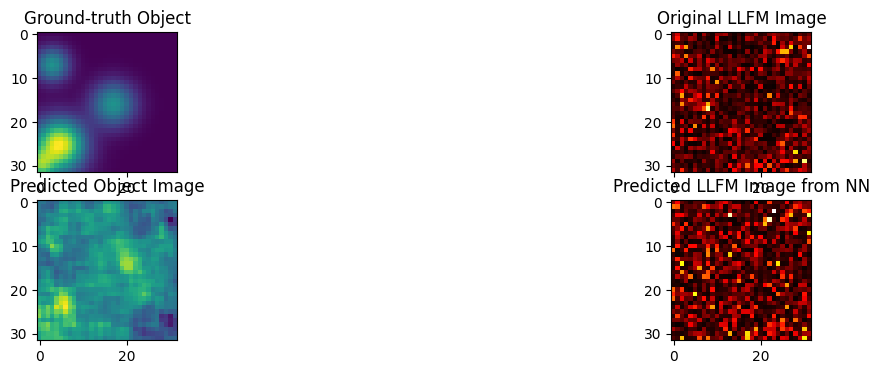

In [23]:


# ----------------------------
# VISUALIZE RESULTS AND RE-PROPAGATE
# ----------------------------
with torch.no_grad():
    pred = model(torch.tensor(X_train[:1], dtype=torch.float32)[:,None]).squeeze().numpy()
    # re-propagate prediction to generate predicted image
    predicted_image = simulate_image(pred, phase_mask, prop_distance, mask_fraction)

plt.figure(figsize=(15,4))
plt.subplot(2,2,1)
plt.imshow(Y_train[0], cmap='viridis')
plt.title('Ground-truth Object')
plt.subplot(2,2,2)
plt.imshow(X_train[0], cmap='hot')
plt.title('Original LLFM Image')
plt.subplot(2,2,3)
plt.imshow(pred, cmap='viridis')
plt.title('Predicted Object Image')
plt.subplot(2,2,4)
plt.imshow(predicted_image, cmap='hot')
plt.title('Predicted LLFM Image from NN')
plt.show()